In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[  0.          25.48860139  48.57030326  69.5813038   82.4548144
 109.4189376  110.44497738 160.29841201 160.30648659 227.12458838
 227.12460681]


In [ ]:
list_c_vals=[np.float64(0.9930733865293206), np.float64(0.9920967260182538), np.float64(0.9909671201993773), np.float64(0.989884569072691), np.float64(0.9886490726381949), np.float64(0.9873606308958891), np.float64(0.9860192438457734), np.float64(0.9845249114878482), np.float64(0.9829776338221131), np.float64(0.9812774108485682), np.float64(0.9794242425672137), np.float64(0.9777181289780494), np.float64(0.9756590700810754), np.float64(0.9734470658762916), np.float64(0.971182116363698), np.float64(0.9686642215432947), np.float64(0.9658933814150816), np.float64(0.9626695959790589), np.float64(0.9594928652352263), np.float64(0.9561631891835839)]

list_ef_AC_stark_vals=[np.float64(1.9848907245309517), np.float64(1.9326217272530353), np.float64(1.8874574125355859), np.float64(1.8532977803786037), np.float64(1.8243428307820888), np.float64(1.7795925637460406), np.float64(1.7607469792704598), np.float64(1.6987060773553462), np.float64(1.6576698580006997), np.float64(1.6236383212065206), np.float64(1.5903114669728082), np.float64(1.5349892952995634), np.float64(1.4927718061867854), np.float64(1.4361589996344748), np.float64(1.3832508756426312), np.float64(1.327347434211255), np.float64(1.2630486753403458), np.float64(1.2030545990299033), np.float64(1.1460652052799285), np.float64(1.0801804940904207)]


## Simulaatio

In [5]:
f_1 = qubit.frequency*1.2 #Ajotaajuudet
f_2 = qubit.frequency*1.4
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

dim = 7 #Hilbert-avaruuden dimensio

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

In [6]:
def find_params(f_1,f_2,A,evolution,f_rabi,AC_stark,lims,scale):

    #Rajat AC-stark siirtymälle
    min_range = lims[0]
    max_range = lims[1]
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]
    
    for i in range(min_range, max_range):
        delta = AC_stark+i/scale
        AC_stark_vals.append(delta)
        
        if A < 2.9:
            sim_vals = pulses.sim_3_part_pulses(f_1,f_ef+delta,A,evolution,dim,f_rabi,t_ramp=5,U_f=10,f_2=f_2,K=200, drag=True)
        elif A < 3.7:
            sim_vals = pulses.sim_3_part_pulses(f_1,f_ef+delta,A,evolution,dim,f_rabi,t_ramp=5,U_f=5,f_2=f_2,K=200, drag=True)
        else:
            sim_vals = pulses.sim_3_part_pulses(f_1,f_ef+delta,A,evolution,dim,f_rabi,t_ramp=5,U_f=1,f_2=f_2,K=200, drag=True)

        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.plot(AC_stark_vals, max_e_vals)
    plt.xlabel("delta=ω_q-2ω_1+ω_2 (GHz)")
    plt.ylabel("Suurin e-tason todennäköisyys")
    plt.show()
    
    index=np.argmax(max_e_vals)
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    delta=AC_stark_vals[index]
    pi_pulse=pulse_times[index]
    
    return(delta,pi_pulse,[e_max,f_max],max_e_vals)

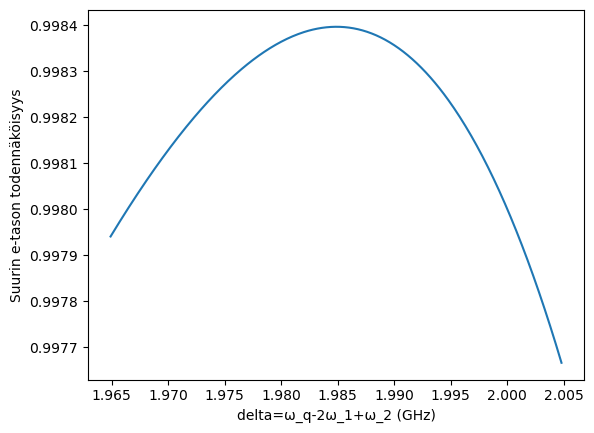

Amplitudi (GHz): 2.0390881111606896
AC-stark siirtymä (GHz): 1.9848907245309517
E-tason suurin todennäköisyys: 0.9987921365234977
Pulssin pituus (ns): 208.5832008152977
Rabi-taajuus (fourier):  0.0025291270883155085


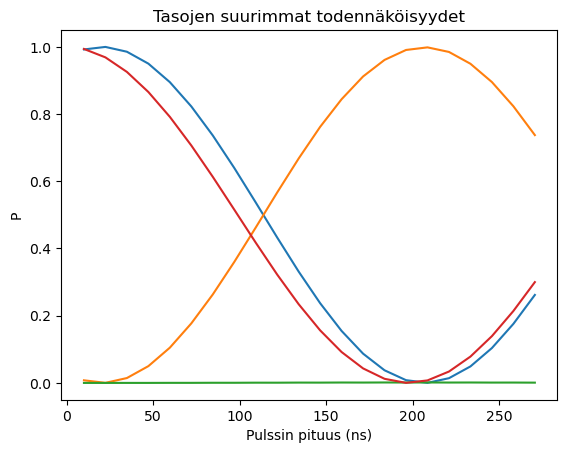

---------------------------------------------


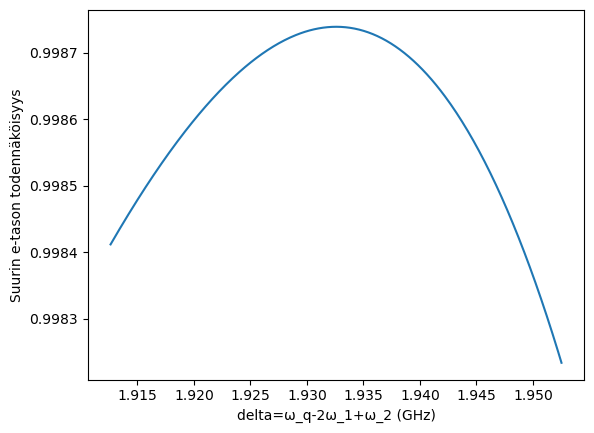

Amplitudi (GHz): 2.173238644789682
AC-stark siirtymä (GHz): 1.9326217272530353
E-tason suurin todennäköisyys: 0.9987393818319121
Pulssin pituus (ns): 171.5076890567263
Rabi-taajuus (fourier):  0.003078910747018282


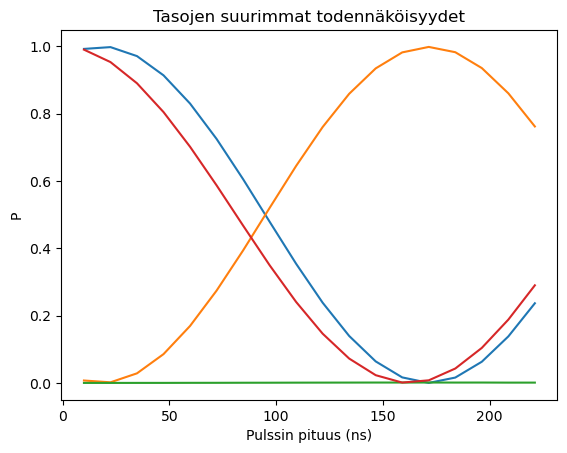

---------------------------------------------


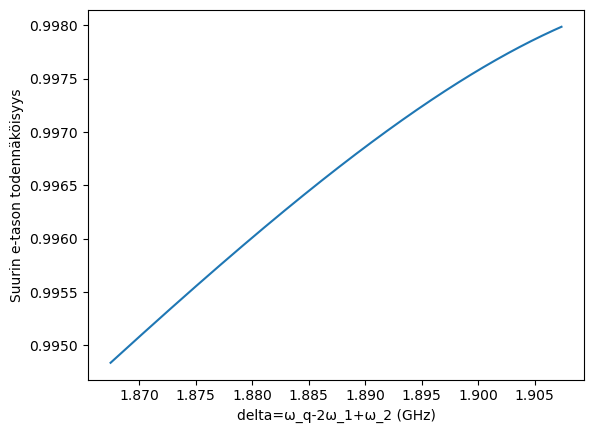

Amplitudi (GHz): 2.307389178418675
AC-stark siirtymä (GHz): 1.9073574125355859
E-tason suurin todennäköisyys: 0.9979861560682026
Pulssin pituus (ns): 146.8023268141436
Rabi-taajuus (fourier):  0.0037029994969065634


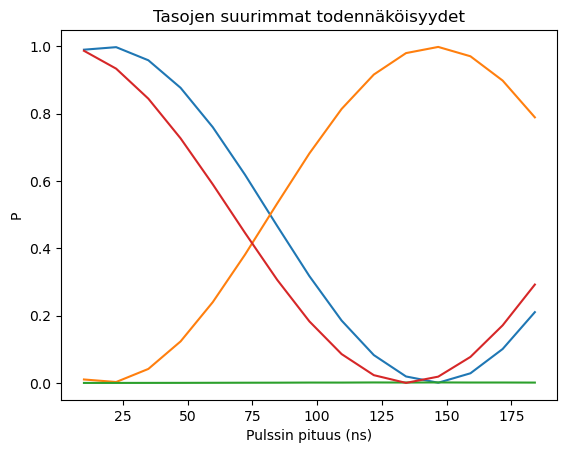

---------------------------------------------


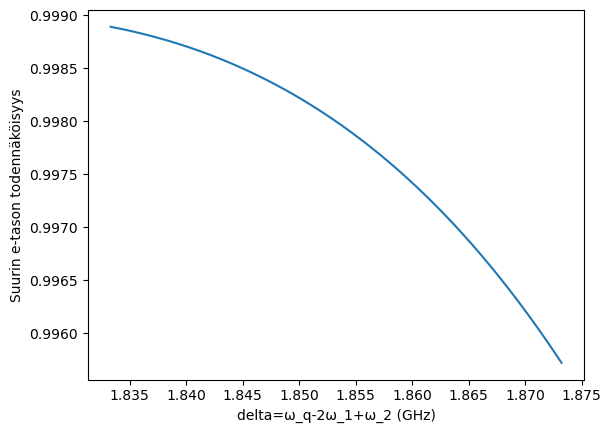

Amplitudi (GHz): 2.4415397120476676
AC-stark siirtymä (GHz): 1.8332977803786037
E-tason suurin todennäköisyys: 0.9988931412436625
Pulssin pituus (ns): 122.06289103839585
Rabi-taajuus (fourier):  0.004392064986359873


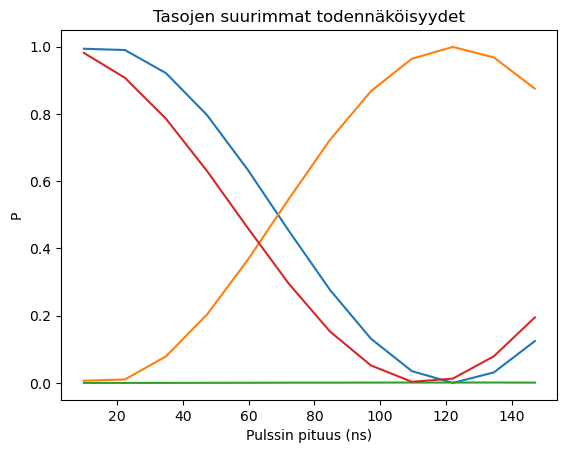

---------------------------------------------


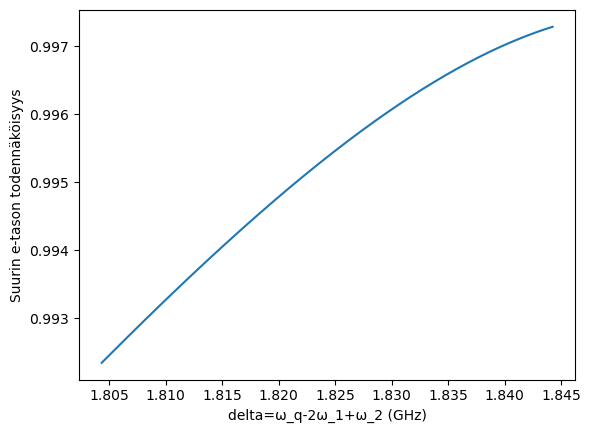

Amplitudi (GHz): 2.57569024567666
AC-stark siirtymä (GHz): 1.8442428307820888
E-tason suurin todennäköisyys: 0.9974009482420583
Pulssin pituus (ns): 109.72585421257958
Rabi-taajuus (fourier):  0.005199439228800426


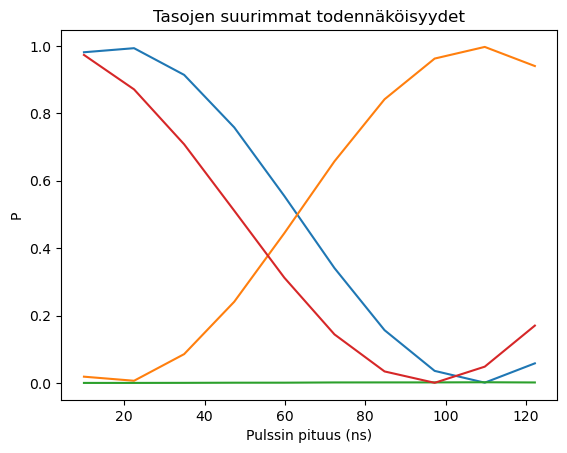

---------------------------------------------


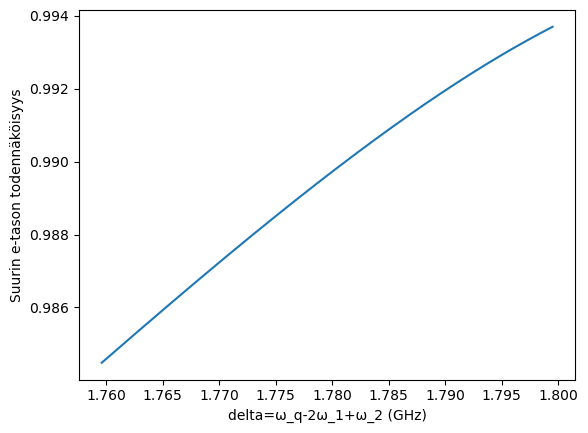

Amplitudi (GHz): 2.7098407793056527
AC-stark siirtymä (GHz): 1.7994925637460406
E-tason suurin todennäköisyys: 0.9982036143609682
Pulssin pituus (ns): 97.37397971868509
Rabi-taajuus (fourier):  0.006095735794191764


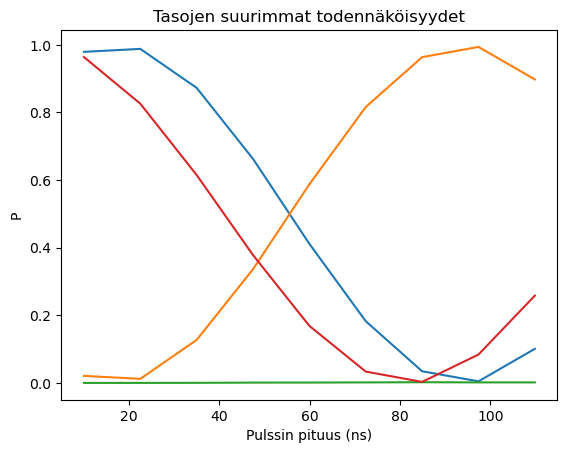

---------------------------------------------


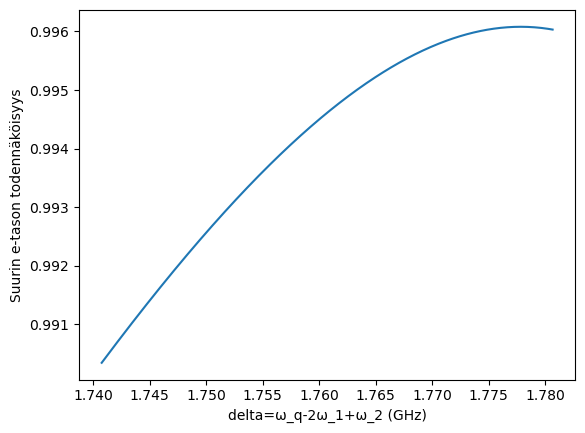

Amplitudi (GHz): 2.8439913129346457
AC-stark siirtymä (GHz): 1.7778469792704596
E-tason suurin todennäköisyys: 0.9978302519098257
Pulssin pituus (ns): 84.99385582888084
Rabi-taajuus (fourier):  0.007089188357421561


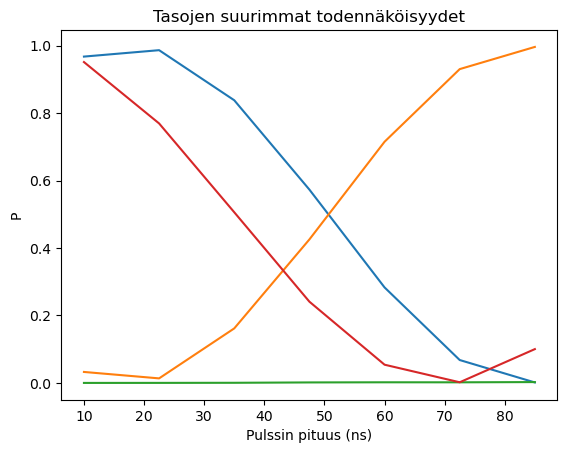

---------------------------------------------


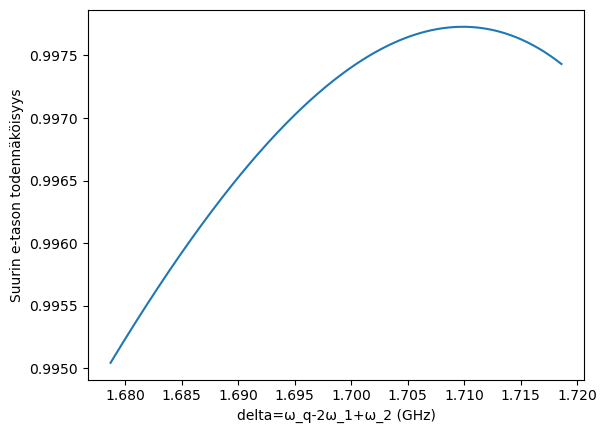

Amplitudi (GHz): 2.9781418465636382
AC-stark siirtymä (GHz): 1.7099060773553463
E-tason suurin todennäköisyys: 0.9977288925914687
Pulssin pituus (ns): 72.58972625026158
Rabi-taajuus (fourier):  0.009329671829919143


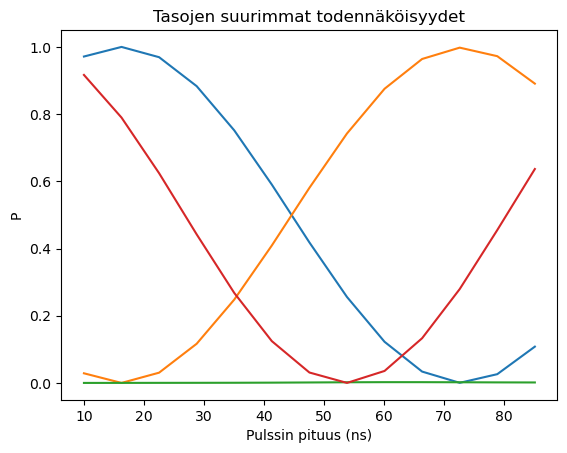

---------------------------------------------


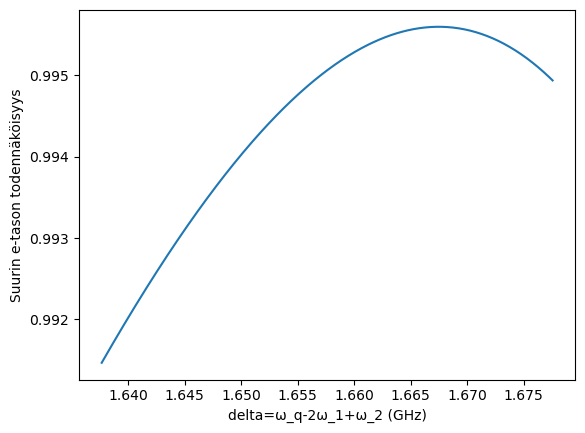

Amplitudi (GHz): 3.112292380192631
AC-stark siirtymä (GHz): 1.6674698580006997
E-tason suurin todennäköisyys: 0.9975846416856876
Pulssin pituus (ns): 66.4251529168857
Rabi-taajuus (fourier):  0.010813785341870566


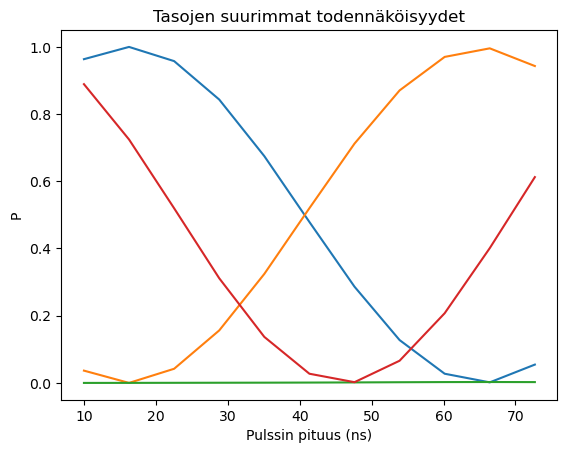

---------------------------------------------


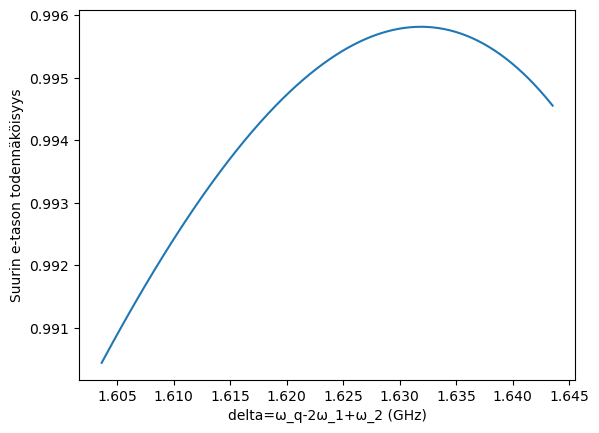

Amplitudi (GHz): 3.2464429138216238
AC-stark siirtymä (GHz): 1.6318383212065206
E-tason suurin todennäköisyys: 0.9964053428110874
Pulssin pituus (ns): 60.237474788358966
Rabi-taajuus (fourier):  0.010928487352440659


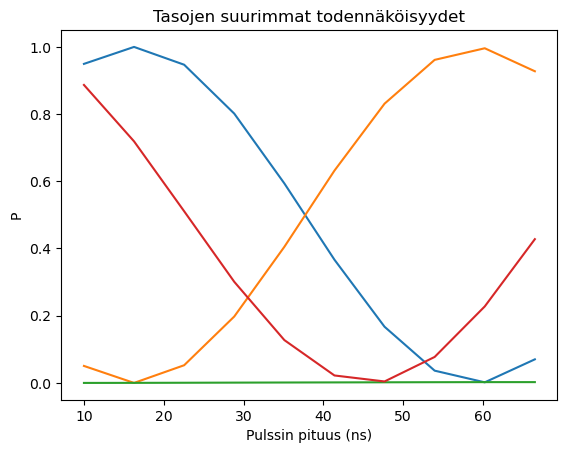

---------------------------------------------


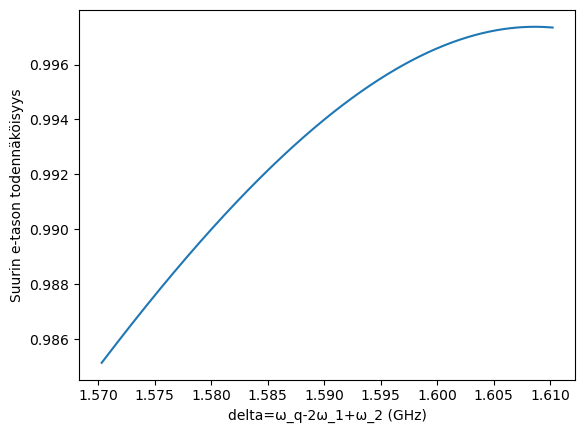

Amplitudi (GHz): 3.3805934474506167
AC-stark siirtymä (GHz): 1.6086114669728082
E-tason suurin todennäköisyys: 0.9973768187263624
Pulssin pituus (ns): 54.02297717977904
Rabi-taajuus (fourier):  0.012506237265699905


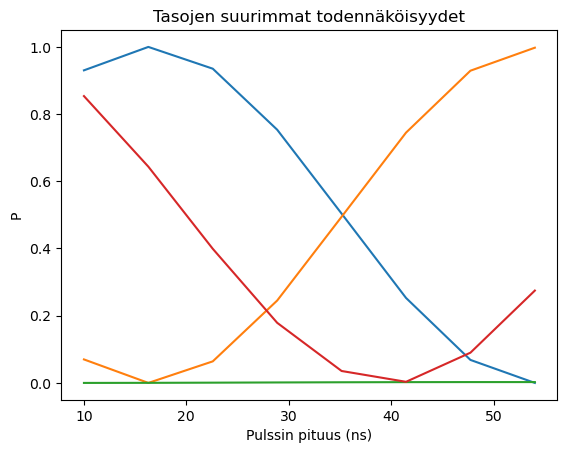

---------------------------------------------


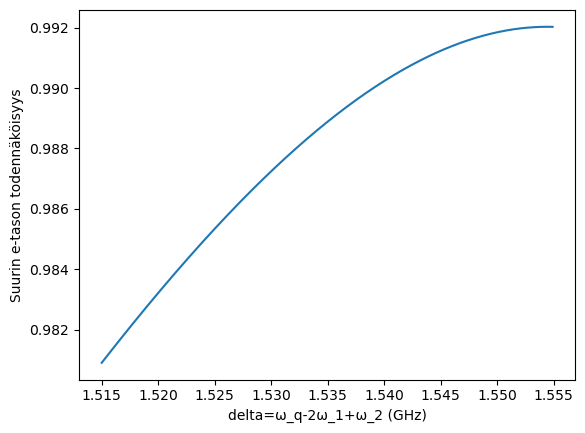

Amplitudi (GHz): 3.5147439810796093
AC-stark siirtymä (GHz): 1.5543892952995635
E-tason suurin todennäköisyys: 0.9928804195722835
Pulssin pituus (ns): 47.80365694699978
Rabi-taajuus (fourier):  0.014243636249700766


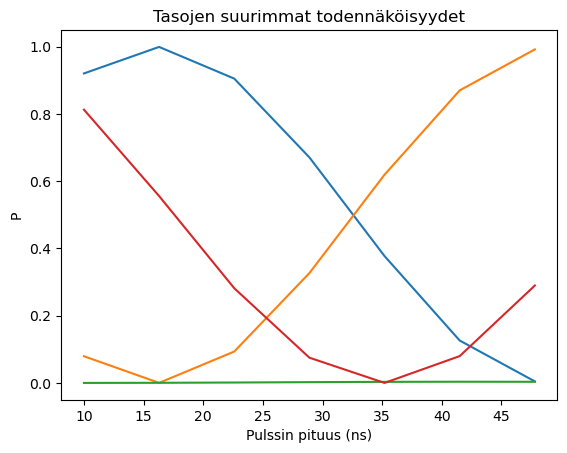

---------------------------------------------


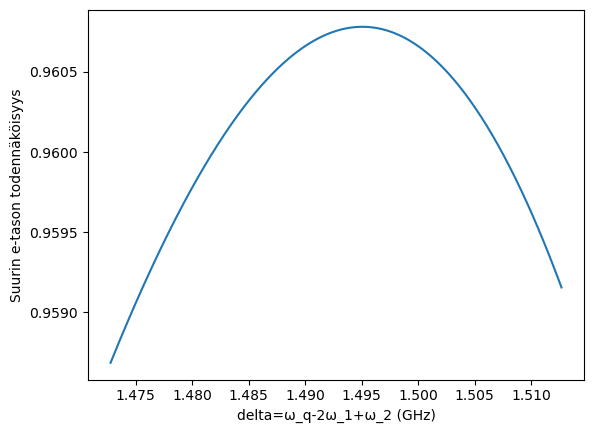

Amplitudi (GHz): 3.648894514708602
AC-stark siirtymä (GHz): 1.4950718061867854
E-tason suurin todennäköisyys: 0.991600021984757
Pulssin pituus (ns): 41.56303770068661
Rabi-taajuus (fourier):  0.016307235293190572


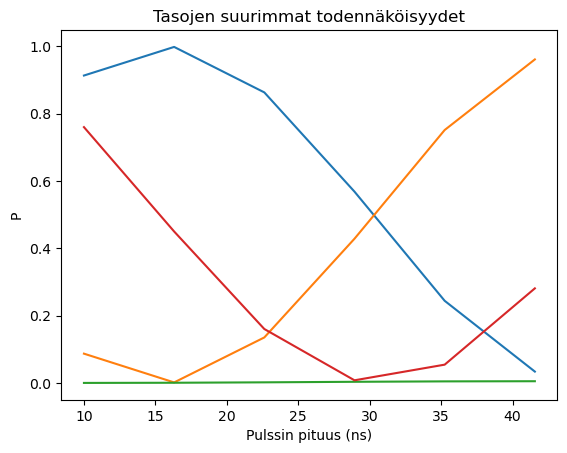

---------------------------------------------


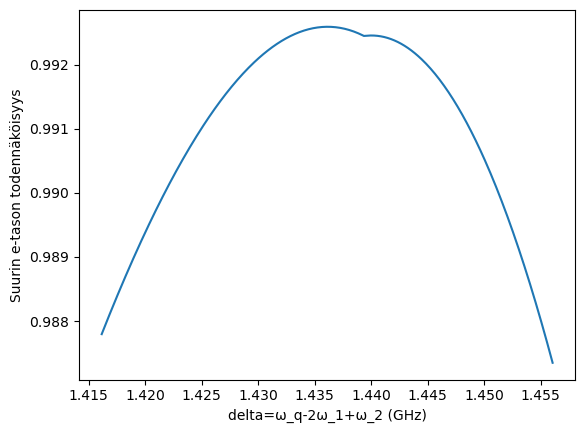

Amplitudi (GHz): 3.783045048337595
AC-stark siirtymä (GHz): 1.4361589996344748
E-tason suurin todennäköisyys: 0.9925928528215344
Pulssin pituus (ns): 40.372445071854955
Rabi-taajuus (fourier):  0.018255212717738965


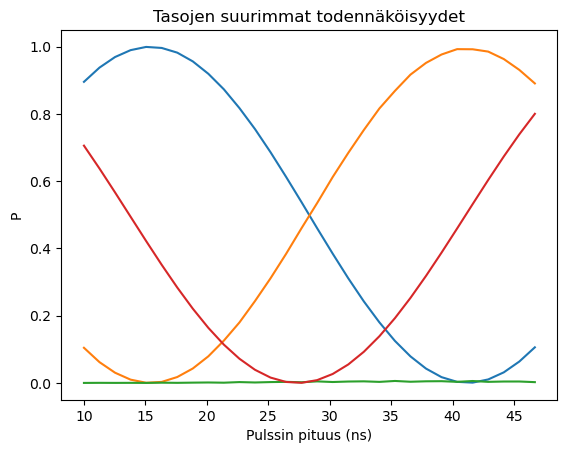

---------------------------------------------


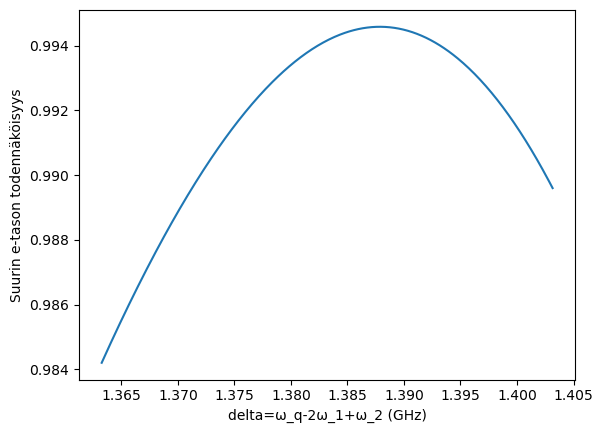

Amplitudi (GHz): 3.9171955819665873
AC-stark siirtymä (GHz): 1.387850875642631
E-tason suurin todennäköisyys: 0.9947654920136884
Pulssin pituus (ns): 37.90056238086605
Rabi-taajuus (fourier):  0.02067266667759995


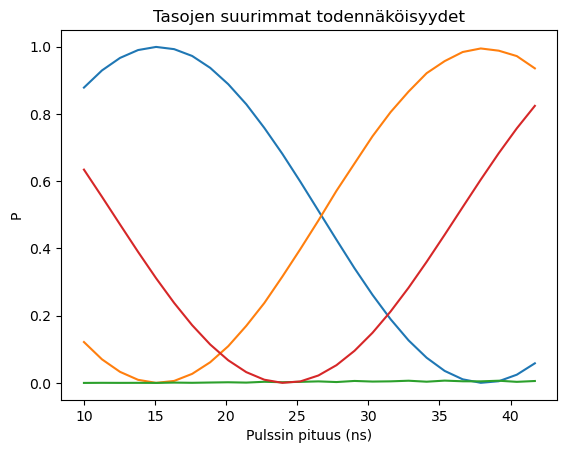

---------------------------------------------


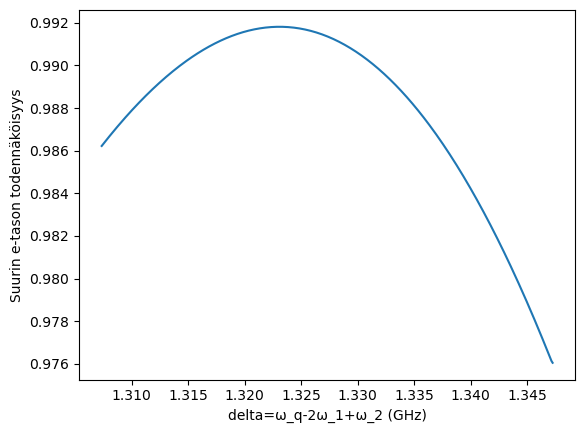

Amplitudi (GHz): 4.05134611559558
AC-stark siirtymä (GHz): 1.323047434211255
E-tason suurin todennäköisyys: 0.9941737287562714
Pulssin pituus (ns): 35.427407138803936
Rabi-taajuus (fourier):  0.0232315192954371


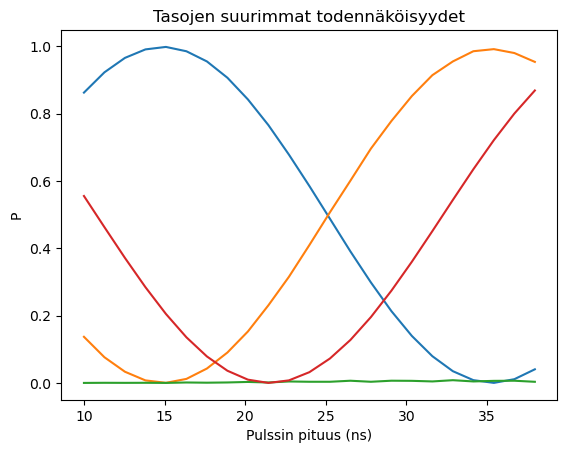

---------------------------------------------


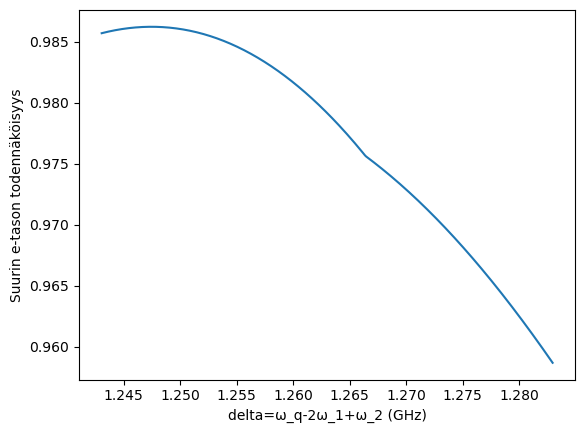

Amplitudi (GHz): 4.185496649224572
AC-stark siirtymä (GHz): 1.2474486753403458
E-tason suurin todennäköisyys: 0.9942345427128632
Pulssin pituus (ns): 32.95026090738304
Rabi-taajuus (fourier):  0.02601959082356933


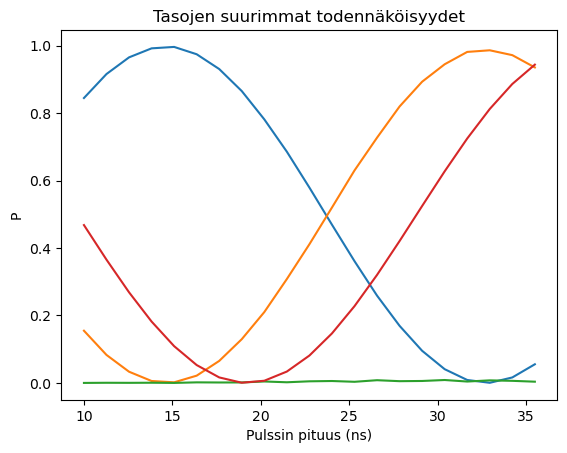

---------------------------------------------


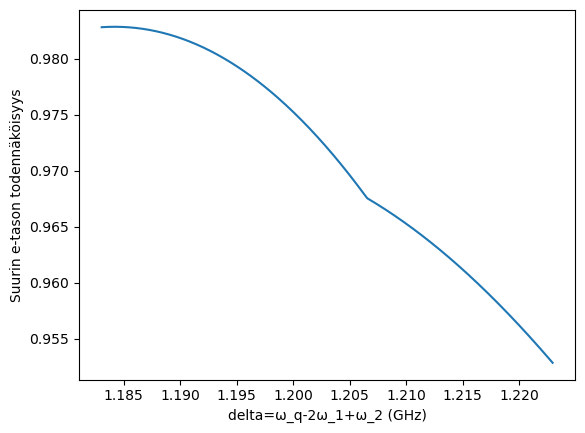

Amplitudi (GHz): 4.319647182853566
AC-stark siirtymä (GHz): 1.1841545990299034
E-tason suurin todennäköisyys: 0.9869659965566832
Pulssin pituus (ns): 30.45363103793236
Rabi-taajuus (fourier):  0.02912659760735018


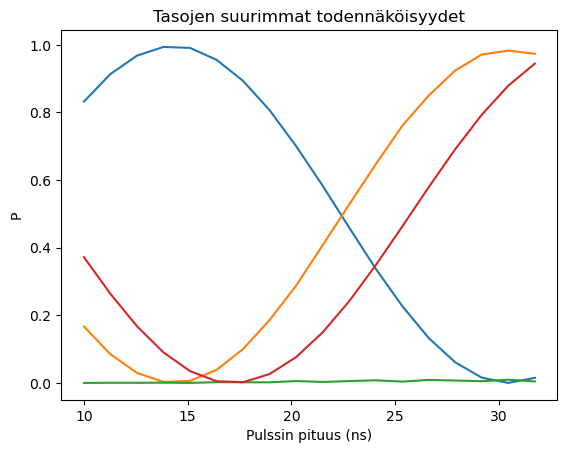

---------------------------------------------


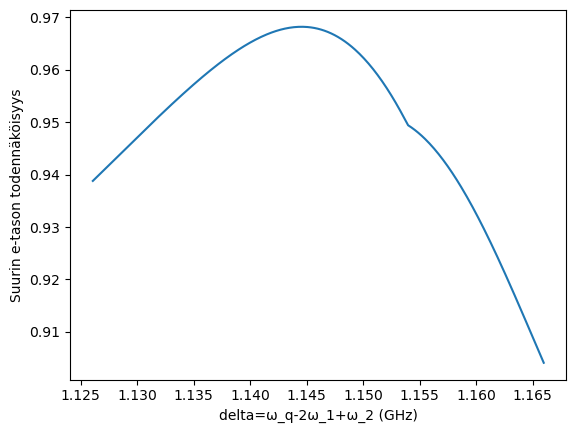

Amplitudi (GHz): 4.453797716482558
AC-stark siirtymä (GHz): 1.1445652052799284
E-tason suurin todennäköisyys: 0.9738569380551397
Pulssin pituus (ns): 25.42463962017561
Rabi-taajuus (fourier):  0.03704647794047236


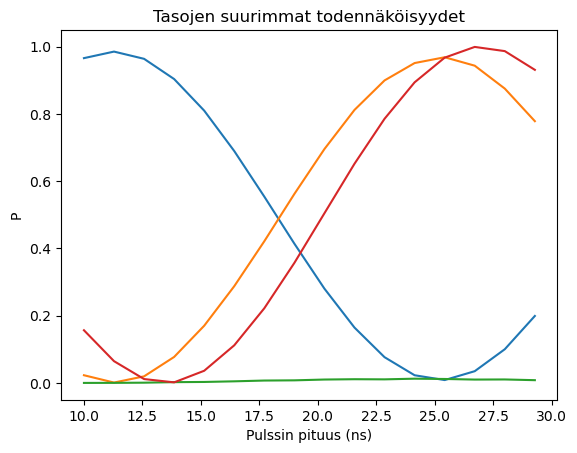

---------------------------------------------


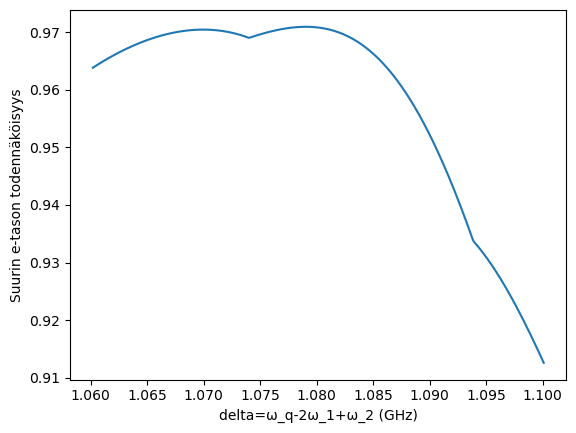

Amplitudi (GHz): 4.587948250111551
AC-stark siirtymä (GHz): 1.0789804940904206
E-tason suurin todennäköisyys: 0.9744845096909156
Pulssin pituus (ns): 24.17220706359273
Rabi-taajuus (fourier):  0.041395575441016956


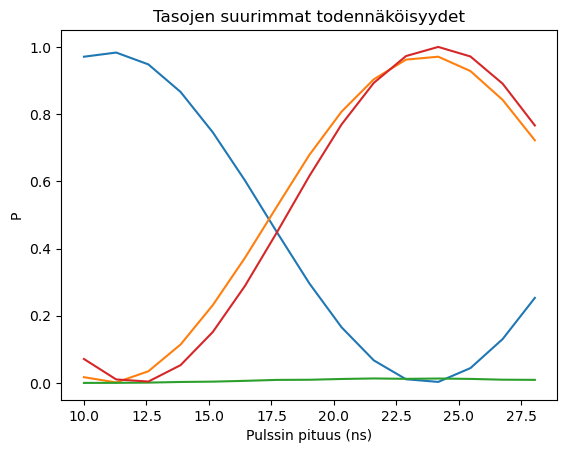

---------------------------------------------


In [7]:
c_vals = [] #c:n arvot
deltas = [] #AC Stark siirtymät
pulse_lengths = [] #Pulssin pituudet
max_vals = [] #Suurimmat tasojen todennäköisyydet
rabis = [] #Rabi taajuudet (fouriermuunnoksesta)
data = [] #e-tason suurimmat todennäköisyydet amplitudin ja AC-stark siirtymän suhteen
A_vals= []

min_range = 0.08
max_range = 0.18
N_data=20
d_data=(max_range-min_range)/(N_data-1)

for i in range (0,N_data):
    
    A = qubit.frequency*(min_range+i*d_data)
    A_vals.append(A)
    
    f_1_opt=f_1*list_c_vals[i]
    f_2_opt=f_2*list_c_vals[i]

    f_rabi= 0.0009703*A**3 - 0.00434*A**2 + 0.009973*A - 0.007682 #Arvaus Rabi-taajuudelle
    AC_stark=list_ef_AC_stark_vals[i]

    params=find_params(f_1_opt,f_2_opt, A, evolution_eigenbasis,8*f_rabi,AC_stark,[-200,200],10000)
    deltas.append(params[0])
    pulse_lengths.append(params[1])
    data.append(params[3])

    m=10

    if A < 2.9:
        vals = pulses.sim_3_part_pulses(f_1_opt,f_ef+deltas[-1],A,evolution_eigenbasis,dim,(f_rabi*8)/m,t_ramp=5,U_f=10,f_2=f_2_opt,K=200, drag=True)
    elif A < 3.7:
        vals = pulses.sim_3_part_pulses(f_1_opt,f_ef+deltas[-1],A,evolution_eigenbasis,dim,(f_rabi*8)/m,t_ramp=5,U_f=5,f_2=f_2_opt,K=200, drag=True)
    else:
        vals = pulses.sim_3_part_pulses(f_1_opt,f_ef+deltas[-1],A,evolution_eigenbasis,dim,(f_rabi*8)/m,t_ramp=5,U_f=1,f_2=f_2_opt,K=200, drag=True)
    
    print("Amplitudi (GHz):", A)
    print("AC-stark siirtymä (GHz):", deltas[-1])

    print("E-tason suurin todennäköisyys:", vals[0])
    print("Pulssin pituus (ns):", pulse_lengths[-1])

    g_vals=np.array([arr[0] for arr in vals[3]])
    e_vals=np.array([arr[1] for arr in vals[3]])
    f_vals=np.array([arr[2] for arr in vals[3]])

    max_vals.append([vals[0],vals[1]])

    g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
    fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

    magnitude = np.abs(fft_vals) #Taajuuskomponentit
    magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

    #Taajuusavaruus
    freqs = np.fft.rfftfreq(len(g_vals), d=vals[4][1]-vals[4][0]) 
    frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
    print("Rabi-taajuus (fourier): ",frequency)
    rabis.append(frequency)

    n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä
    
    plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

    plt.figure()
    plt.plot(vals[4][:n_picked], g_vals[:n_picked])
    plt.plot(vals[4][:n_picked], e_vals[:n_picked])
    plt.plot(vals[4][:n_picked], f_vals[:n_picked])
    plt.plot(vals[4][:n_picked], plot_vals)
    plt.xlabel("Pulssin pituus (ns)")
    plt.ylabel("P")
    plt.title("Tasojen suurimmat todennäköisyydet")
    plt.show()

    print("---------------------------------------------")

In [8]:
print(f_ef-qubit.frequency)

-2.4068995201121837


[np.float64(2.0390881111606896), np.float64(2.173238644789682), np.float64(2.307389178418675), np.float64(2.4415397120476676), np.float64(2.57569024567666), np.float64(2.7098407793056527), np.float64(2.8439913129346457), np.float64(2.9781418465636382), np.float64(3.112292380192631), np.float64(3.2464429138216238), np.float64(3.3805934474506167), np.float64(3.5147439810796093), np.float64(3.648894514708602), np.float64(3.783045048337595), np.float64(3.9171955819665873), np.float64(4.05134611559558), np.float64(4.185496649224572), np.float64(4.319647182853566), np.float64(4.453797716482558), np.float64(4.587948250111551)]


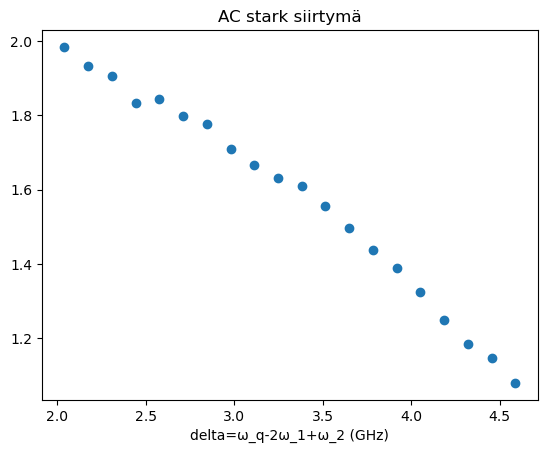

[np.float64(1.9848907245309517), np.float64(1.9326217272530353), np.float64(1.9073574125355859), np.float64(1.8332977803786037), np.float64(1.8442428307820888), np.float64(1.7994925637460406), np.float64(1.7778469792704596), np.float64(1.7099060773553463), np.float64(1.6674698580006997), np.float64(1.6318383212065206), np.float64(1.6086114669728082), np.float64(1.5543892952995635), np.float64(1.4950718061867854), np.float64(1.4361589996344748), np.float64(1.387850875642631), np.float64(1.323047434211255), np.float64(1.2474486753403458), np.float64(1.1841545990299034), np.float64(1.1445652052799284), np.float64(1.0789804940904206)]
[]


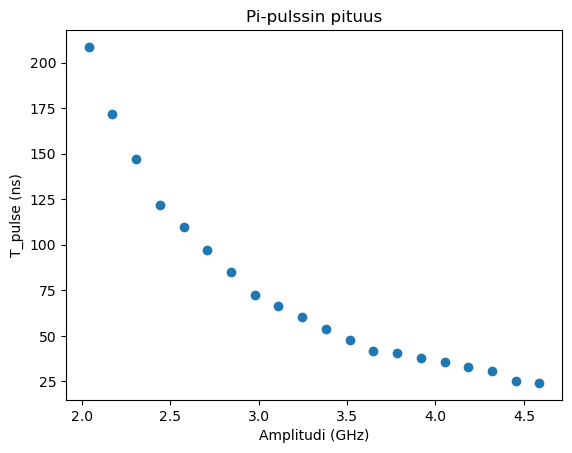

[np.float64(208.5832008152977), np.float64(171.5076890567263), np.float64(146.8023268141436), np.float64(122.06289103839585), np.float64(109.72585421257958), np.float64(97.37397971868509), np.float64(84.99385582888084), np.float64(72.58972625026158), np.float64(66.4251529168857), np.float64(60.237474788358966), np.float64(54.02297717977904), np.float64(47.80365694699978), np.float64(41.56303770068661), np.float64(40.372445071854955), np.float64(37.90056238086605), np.float64(35.427407138803936), np.float64(32.95026090738304), np.float64(30.45363103793236), np.float64(25.42463962017561), np.float64(24.17220706359273)]


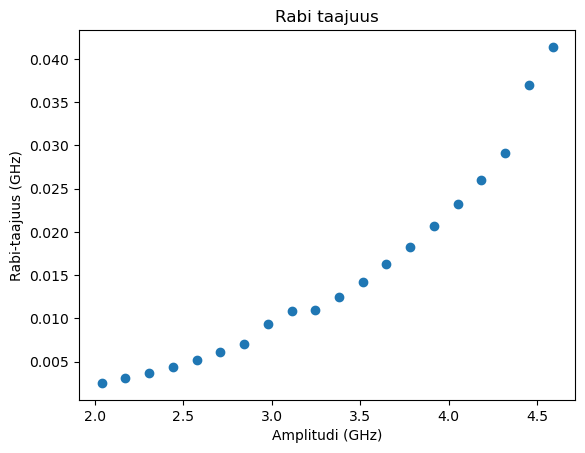

[np.float64(0.0025291270883155085), np.float64(0.003078910747018282), np.float64(0.0037029994969065634), np.float64(0.004392064986359873), np.float64(0.005199439228800426), np.float64(0.006095735794191764), np.float64(0.007089188357421561), np.float64(0.009329671829919143), np.float64(0.010813785341870566), np.float64(0.010928487352440659), np.float64(0.012506237265699905), np.float64(0.014243636249700766), np.float64(0.016307235293190572), np.float64(0.018255212717738965), np.float64(0.02067266667759995), np.float64(0.0232315192954371), np.float64(0.02601959082356933), np.float64(0.02912659760735018), np.float64(0.03704647794047236), np.float64(0.041395575441016956)]


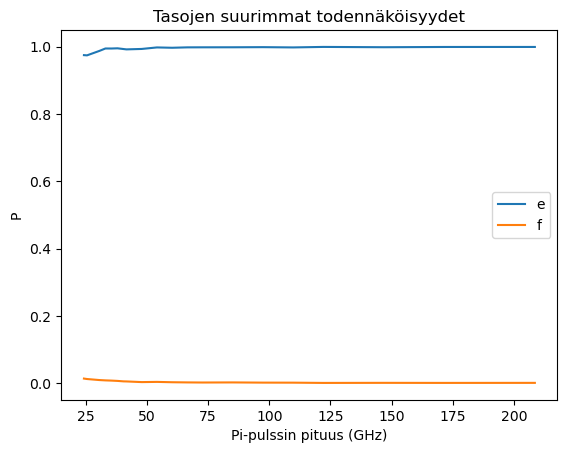

[np.float64(0.9987921365234977), np.float64(0.9987393818319121), np.float64(0.9979861560682026), np.float64(0.9988931412436625), np.float64(0.9974009482420583), np.float64(0.9982036143609682), np.float64(0.9978302519098257), np.float64(0.9977288925914687), np.float64(0.9975846416856876), np.float64(0.9964053428110874), np.float64(0.9973768187263624), np.float64(0.9928804195722835), np.float64(0.991600021984757), np.float64(0.9925928528215344), np.float64(0.9947654920136884), np.float64(0.9941737287562714), np.float64(0.9942345427128632), np.float64(0.9869659965566832), np.float64(0.9738569380551397), np.float64(0.9744845096909156)]
[np.float64(0.0013859370508523792), np.float64(0.001261155316614624), np.float64(0.0014435456973718999), np.float64(0.0012178329565268491), np.float64(0.0019779907208954677), np.float64(0.0021046975042741207), np.float64(0.0026990023814565463), np.float64(0.0024189556913402333), np.float64(0.002729430220372092), np.float64(0.003241760924491225), np.float64(0

'\nplt.figure(figsize=(6, 6))\nplt.imshow(data, aspect=\'auto\')  # stretches to square\nplt.colorbar(label="e-tason suurin todennäköisyys")\nplt.show() '

In [9]:
print(A_vals)

plt.figure()
plt.plot(A_vals, deltas, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.xlabel("delta=ω_q-2ω_1+ω_2 (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(deltas)
print(c_vals)

plt.figure()
plt.plot(A_vals, pulse_lengths, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("T_pulse (ns)")
plt.title("Pi-pulssin pituus")
plt.show()
print(pulse_lengths)

plt.figure()
plt.plot(A_vals, rabis, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Rabi-taajuus (GHz)")
plt.title("Rabi taajuus")
plt.show()
print(rabis)

e_vals=[arr[0] for arr in max_vals]
f_vals=[arr[1] for arr in max_vals]

plt.figure()
plt.plot(pulse_lengths, e_vals)
plt.plot(pulse_lengths, f_vals)
plt.legend(["e","f"])
plt.xlabel("Pi-pulssin pituus (GHz)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()
print(e_vals)
print(f_vals)

"""
plt.figure(figsize=(6, 6))
plt.imshow(data, aspect='auto')  # stretches to square
plt.colorbar(label="e-tason suurin todennäköisyys")
plt.show() """